In [3]:
import yfinance as yf
import pandas as pd
import datetime as dt

import hist_volatility
from riskfree_and_spot import *
from hist_volatility import *
from blackscholes import *
from binomial import *

In [7]:
data = pd.read_csv("../data/option_data_calc.csv")

In [22]:
spot = get_spot_price_data(valuation_date="2026-08-06", ticker="MSFT")

moneyness_list = []

for i, row in data.iterrows():
    strike = row["strike"]
    moneyness = strike / spot
    moneyness_list.append(moneyness)

data["moneyness"] = moneyness_list
data

[*********************100%***********************]  1 of 1 completed


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiration,tenor,rf_rate,imp_vol,moneyness
0,MSFT260807C00270000,2026-08-03 14:47:55+00:00,270.0,216.18,228.35,232.20,0.000000,0.000000,3.0,5,3.689454,True,REGULAR,USD,2026-08-07,0.008219,0.037800,NaN,0.540151
1,MSFT260807C00280000,2026-06-29 15:30:42+00:00,280.0,95.05,218.35,221.90,0.000000,0.000000,NaN,3,3.294924,True,REGULAR,USD,2026-08-07,0.008219,0.037800,NaN,0.560157
2,MSFT260807C00290000,2026-06-29 15:30:44+00:00,290.0,86.80,208.35,212.20,0.000000,0.000000,NaN,3,3.298830,True,REGULAR,USD,2026-08-07,0.008219,0.037800,NaN,0.580162
3,MSFT260807C00300000,2026-08-06 17:39:41+00:00,300.0,196.11,198.35,202.20,6.860001,3.624835,62.0,153,3.113283,True,REGULAR,USD,2026-08-07,0.008219,0.037800,NaN,0.600168
4,MSFT260807C00305000,2026-08-06 17:39:41+00:00,305.0,191.13,193.30,196.90,113.710010,146.874200,64.0,28,2.814456,True,REGULAR,USD,2026-08-07,0.008219,0.037800,NaN,0.610171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1622,MSFT281215C00710000,2026-08-06 16:39:59+00:00,710.0,55.75,56.00,59.50,1.650001,3.049911,3.0,317,0.387305,False,REGULAR,USD,2028-12-15,2.367123,0.042159,0.344011,1.420398
1623,MSFT281215C00715000,2026-08-05 18:54:20+00:00,715.0,52.00,55.35,58.75,0.000000,0.000000,19.0,868,0.387923,False,REGULAR,USD,2028-12-15,2.367123,0.042159,0.345017,1.430401
1624,MSFT281215C00720000,2026-08-06 19:26:47+00:00,720.0,55.45,54.30,57.35,3.250000,6.226054,89.0,904,0.386259,False,REGULAR,USD,2028-12-15,2.367123,0.042159,0.344173,1.440403
1625,MSFT281215C00725000,2026-08-06 19:23:16+00:00,725.0,54.40,53.30,56.00,2.530003,4.877584,142.0,1780,0.384703,False,REGULAR,USD,2028-12-15,2.367123,0.042159,0.343435,1.450406


In [32]:
iv_fig_data = data[
    (data["bid"] > 0) &
    (data["ask"] > 0) &
    (data["openInterest"] > 0) &
    (data["inTheMoney"] == True) &
    (data["imp_vol"] > 0) &
    (data["tenor"] > 0.05)
    # (data["strike"] > spot_for_iv * 0.8) &
    # (data["strike"] < spot_for_iv * 1.2)
]

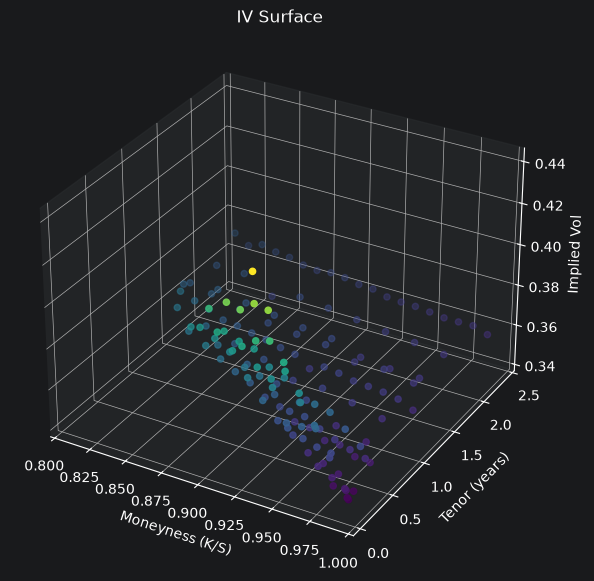

In [33]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(iv_fig_data["moneyness"], iv_fig_data["tenor"], iv_fig_data["imp_vol"], c=iv_fig_data["imp_vol"], cmap="viridis")
ax.set_xlabel("Moneyness (K/S)")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
ax.set_title(f"IV Surface")
plt.show()

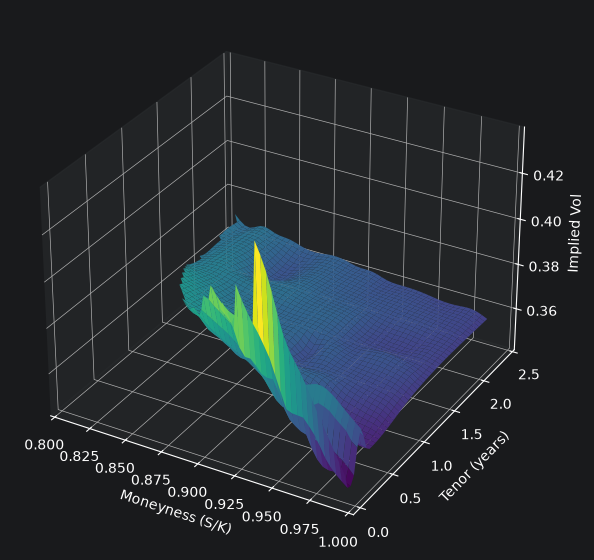

In [34]:
from scipy.interpolate import griddata

strikes = np.linspace(iv_fig_data["moneyness"].min(), iv_fig_data["moneyness"].max(), 50)
tenors = np.linspace(iv_fig_data["tenor"].min(), iv_fig_data["tenor"].max(), 50)
grid_x, grid_y = np.meshgrid(strikes, tenors)

grid_z = griddata(
    (iv_fig_data["moneyness"], iv_fig_data["tenor"]),
    iv_fig_data["imp_vol"],
    (grid_x, grid_y),
    method="cubic"
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_x, grid_y, grid_z, cmap="viridis")
ax.set_xlabel("Moneyness (S/K)")
ax.set_ylabel("Tenor (years)")
ax.set_zlabel("Implied Vol")
plt.show()